In [15]:
import sys
import os
import numpy as np
import importlib

# Remontée de deux niveaux pour accéder à Data_loader
current_dir = os.getcwd()
project_root = os.path.normpath(os.path.join(current_dir, "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Chemin du projet : {project_root}")

# Import du module de chargement des données
module_name = "RSA_deep_working.Data_loader.class_data_loaders"

try:
    class_data_loaders = importlib.import_module(module_name)
    DirectoryRSAClass = class_data_loaders.DirectoryRSAClass
except ModuleNotFoundError as e:
    print(f"Erreur lors de l'importation du module {module_name} : {e}")
    sys.exit(1)

Chemin du projet : /home/loai/Test/RSMLExtraction


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import rsml
import tifffile


from RSA_deep_working.Data_loader.class_data_loaders import DirectoryRSAClass

# importing pretrained segmentation model
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/uc1_segmentation")
global_step = 0


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader

# Dimensions d'origine
H, W = (1166, 1348)

# Première étape : division par 4
H_temp = H // 4  # 1166 // 4 = 291
W_temp = W // 4  # 1348 // 4 = 337

# Deuxième étape : ajustement pour être divisible par 32
H_new = (H_temp // 32) * 32  # 291 // 32 = 9, 9 * 32 = 288
W_new = (W_temp // 32) * 32  # 337 // 32 = 10, 10 * 32 = 320

print("Dimensions après division par 4 :", H_temp, W_temp)
print("Dimensions ajustées (multiples de 32) :", H_new, W_new)

img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

mask_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.NEAREST),
])

class RSASeg2DDataset(Dataset):
    def __init__(self, rsa_dir_loader, img_transform=None, mask_transform=None):
        self.samples = []
        self.img_transform = img_transform
        self.mask_transform = mask_transform
        for loader in rsa_dir_loader.loaders:
            img_path = loader.image_stack_path
            mask_path = loader.date_map_path
            with tifffile.TiffFile(img_path) as tif:
                num_slices = len(tif.pages)
            for z in range(num_slices):
                self.samples.append((img_path, mask_path, z))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, z = self.samples[idx]
        img = tifffile.imread(img_path, key=z)
        mask_loaded = tifffile.imread(mask_path)
        mask = np.zeros_like(img)
        mask[mask_loaded <= z + 1] = 1
        mask[mask_loaded == 0] = 0
        mask = mask.astype(np.float32)


        if self.img_transform:
            img = self.img_transform(img)
            mask = self.mask_transform(mask)
        return img, mask

# Instanciation
base_directory = "/home/loai/Test/data/UC1_data"
dir_loader = DirectoryRSAClass(base_directory, load_date_map=True, lazy=True)
rsa_dataset = RSASeg2DDataset(dir_loader, img_transform=img_transform, mask_transform=mask_transform)

print(len(rsa_dataset))

# plot image and mask
def plot_img_mask(img: torch.Tensor, mask: torch.Tensor):
    # img et mask ont shape [1, H, W]
    img_np  = img.squeeze(0).cpu().numpy()   # → (H, W)
    mask_np = mask.squeeze(0).cpu().numpy()

    fig, (ax0, ax1) = plt.subplots(1,2, figsize=(10,5))
    ax0.imshow(img_np, cmap='gray')
    ax0.set_title("Image")
    ax1.imshow(mask_np, cmap='gray')
    ax1.set_title("Mask")
    plt.show()
    print(f"Image shape : {img_np.shape}, mask shape : {mask_np.shape}")
    # Affichage de superposition
    fig, ax = plt.subplots(1,1, figsize=(5,5))
    ax.imshow(img_np, cmap='gray')
    ax.imshow(mask_np, cmap='jet', alpha=0.5)
    ax.set_title("Superposition")
    plt.show()


# Instanciation
print(len(rsa_dataset))

train_set, val_set = torch.utils.data.random_split(rsa_dataset, [int(0.8*len(rsa_dataset)), len(rsa_dataset)-int(0.8*len(rsa_dataset))])
print(len(train_set) , len(val_set))
def evaluate(model, loader, device, loss_fn):
    model.eval()
    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    n = 0

    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Evaluation iteration", position=1, leave=False, dynamic_ncols=True):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss_val = loss_fn(torch.sigmoid(preds), masks)
            total_loss += loss_val.item()

            probs = torch.sigmoid(preds)
            preds_bin = (probs > 0.5).float()
            intersection = (preds_bin * masks).sum(dim=(1,2,3))
            union = preds_bin.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) - intersection

            iou = (intersection / (union + 1e-6)).mean().item()
            dice = (2 * intersection / (preds_bin.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3)) + 1e-6)).mean().item()

            total_iou += iou
            total_dice += dice
            n += 1

    return total_loss / n, total_iou / n, total_dice / n


Dimensions après division par 4 : 291 337
Dimensions ajustées (multiples de 32) : 288 320
754
754
603 151


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

# data loader optimization
train_loader = DataLoader(train_set, batch_size=16, shuffle=True, num_workers=4)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, num_workers=4)

Utilisation du device : cuda


In [19]:
# load models : model_DICE.pth, model_CLDice.pth, model_BCE.pth
model_BCE = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    # "efficientnet-b0",
    decoder_attention_type="scse",
    in_channels=1,
    classes=1
).to(device)

model_DICE = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    # "efficientnet-b0",
    decoder_attention_type="scse",
    in_channels=1,
    classes=1
).to(device)

model_CLDice = smp.Unet(
    encoder_name="efficientnet-b0",
    encoder_weights="imagenet",
    # "efficientnet-b0",
    decoder_attention_type="scse",
    in_channels=1,
    classes=1
).to(device)

# load models
model_BCE.load_state_dict(torch.load("model_BCE.pth"))
model_DICE.load_state_dict(torch.load("model_DICE.pth"))
model_CLDice.load_state_dict(torch.load("model_CLDice.pth"))

/tmp/ipykernel_2934710/3598057025.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_BCE.load_state_dict(torch.load("model_BCE.pth"))
/tmp/ipykernel_2934710/35980570

<All keys matched successfully>

torch.Size([16, 1, 288, 320]) torch.Size([16, 1, 288, 320])
torch.Size([16, 1, 288, 320]) torch.Size([16, 1, 288, 320]) torch.Size([16, 1, 288, 320])
BCE model


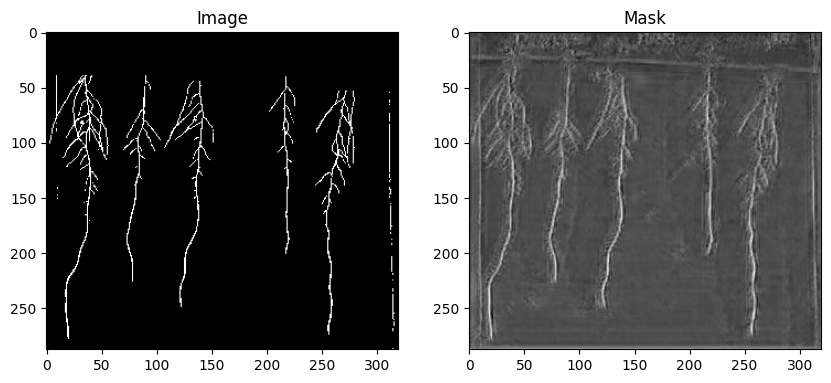

Image shape : (288, 320), mask shape : (288, 320)


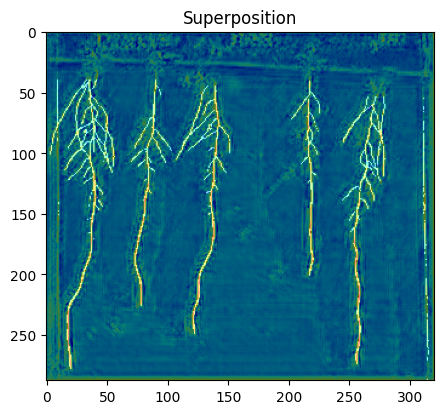

DICE model


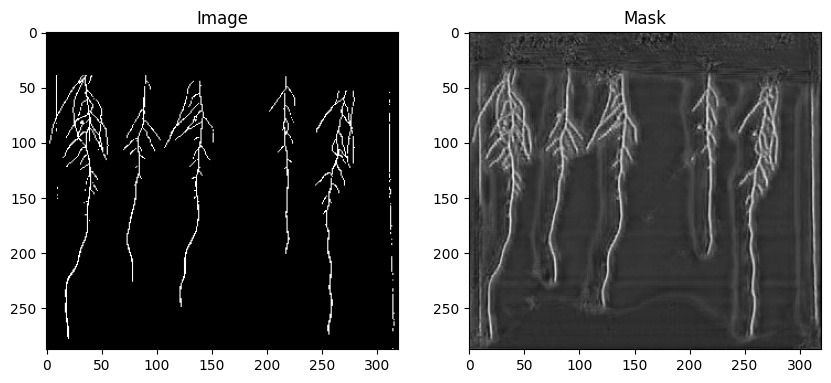

Image shape : (288, 320), mask shape : (288, 320)


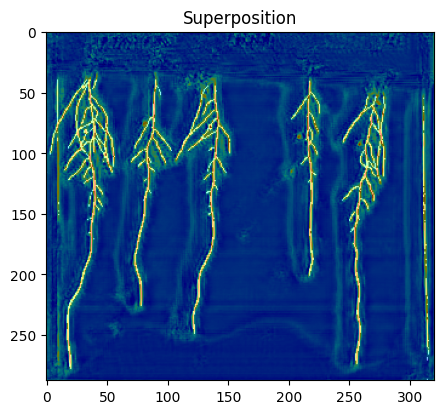

CLDice model


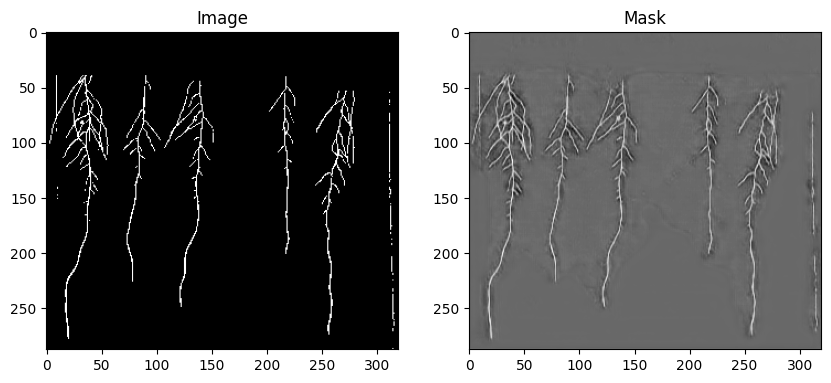

Image shape : (288, 320), mask shape : (288, 320)


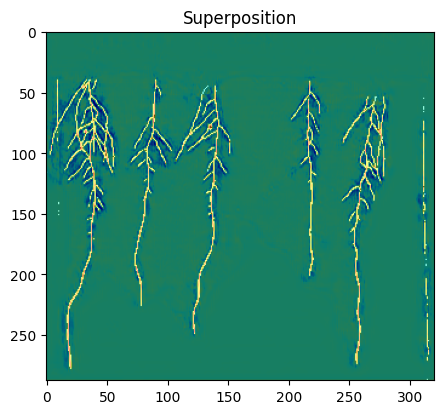

In [20]:
# print output shape and plot of model
batch = next(iter(train_loader))
imgs, masks = batch
imgs, masks = imgs.to(device), masks.to(device)
print(imgs.shape, masks.shape)
preds_BCE = model_BCE(imgs)
preds_DICE = model_DICE(imgs)
preds_CLDice = model_CLDice(imgs)
print(preds_BCE.shape, preds_DICE.shape, preds_CLDice.shape)
print("BCE model")
plot_img_mask(masks[0], preds_BCE[0].detach().cpu())
print("DICE model")
plot_img_mask(masks[0], preds_DICE[0].detach().cpu())
print("CLDice model")
plot_img_mask(masks[0], preds_CLDice[0].detach().cpu())

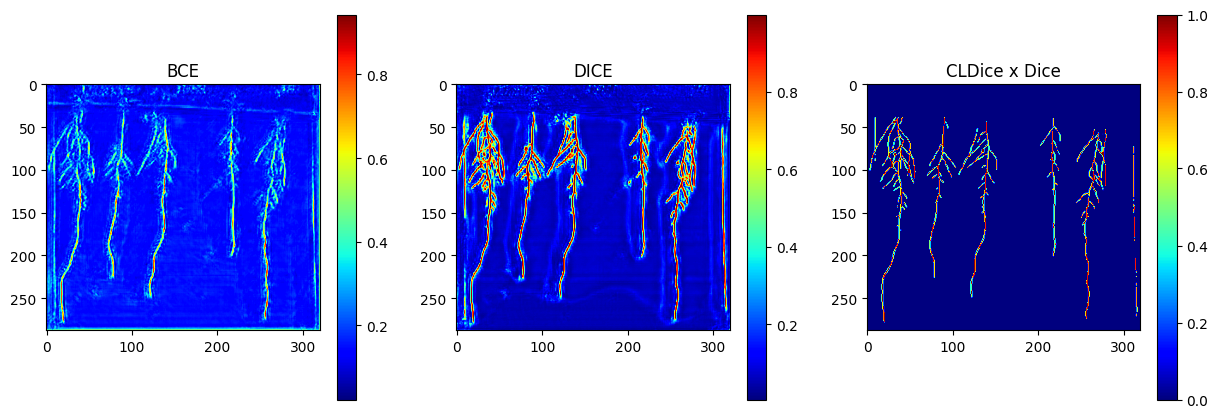

In [21]:
# plot prediction as probability map (density map)
fig, (ax0, ax1, ax2) = plt.subplots(1,3, figsize=(15,5))
ax0.imshow(torch.sigmoid(preds_BCE[0].detach().cpu()).squeeze(0), cmap='jet')
ax0.set_title("BCE")
ax1.imshow(torch.sigmoid(preds_DICE[0].detach().cpu()).squeeze(0), cmap='jet')
ax1.set_title("DICE")
ax2.imshow(torch.sigmoid(preds_CLDice[0].detach().cpu()).squeeze(0), cmap='jet')
ax2.set_title("CLDice x Dice")
# intensity level bar   
plt.colorbar(ax0.imshow(torch.sigmoid(preds_BCE[0].detach().cpu()).squeeze(0), cmap='jet'), ax=ax0)
plt.colorbar(ax1.imshow(torch.sigmoid(preds_DICE[0].detach().cpu()).squeeze(0), cmap='jet'), ax=ax1)
plt.colorbar(ax2.imshow(torch.sigmoid(preds_CLDice[0].detach().cpu()).squeeze(0), cmap='jet'), ax=ax2)
plt.show()

torch.Size([16, 1, 288, 320]) torch.Size([16, 1, 288, 320])
torch.Size([16, 1, 288, 320]) torch.Size([16, 1, 288, 320]) torch.Size([16, 1, 288, 320])
BCE model


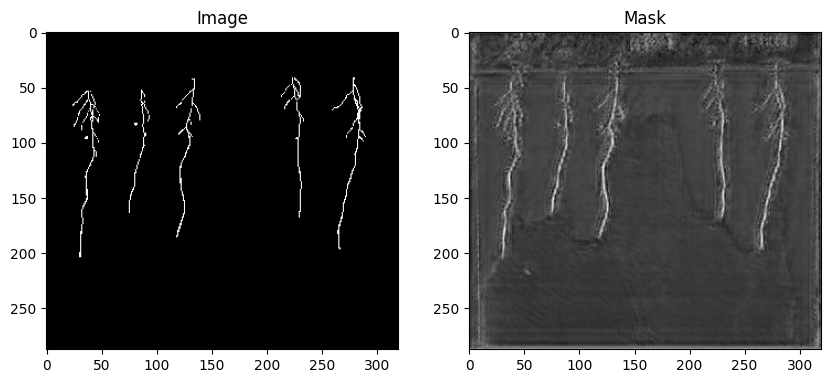

Image shape : (288, 320), mask shape : (288, 320)


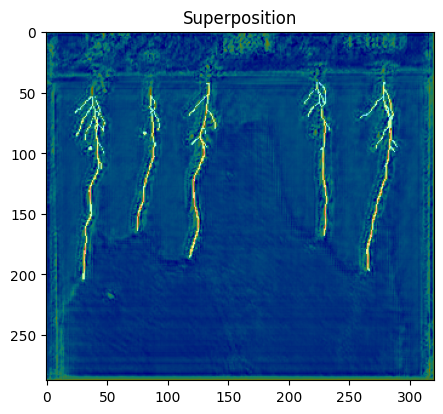

DICE model


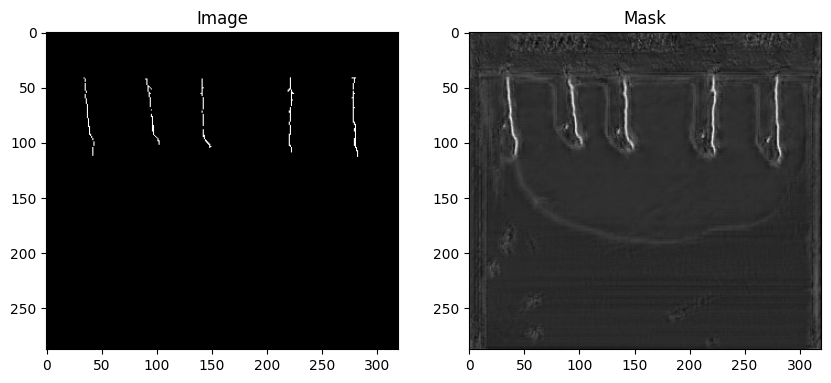

Image shape : (288, 320), mask shape : (288, 320)


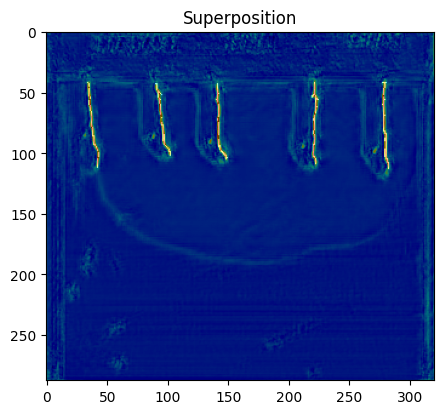

CLDice model


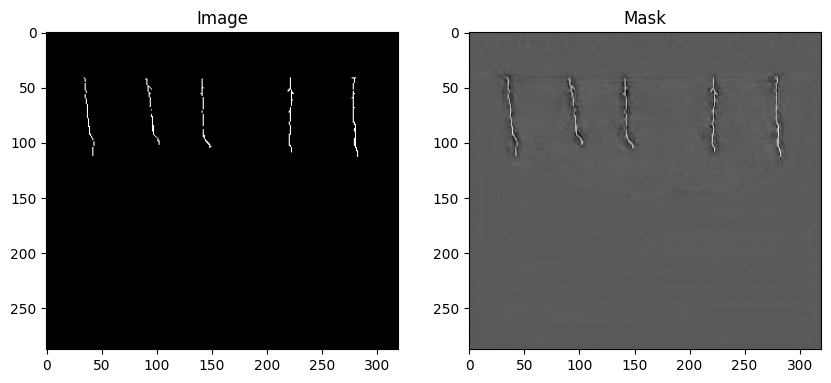

Image shape : (288, 320), mask shape : (288, 320)


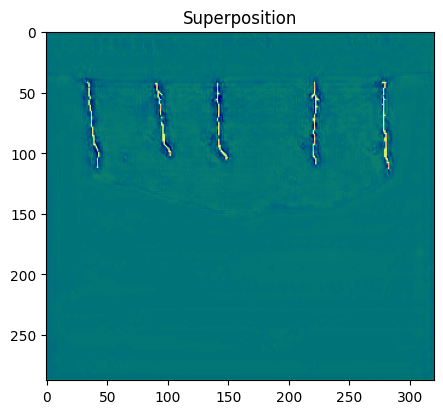

In [25]:
batch = next(iter(val_loader))
# print output shape and plot of model
imgs, masks = batch
imgs, masks = imgs.to(device), masks.to(device)
print(imgs.shape, masks.shape)
preds_BCE = model_BCE(imgs)
preds_DICE = model_DICE(imgs)
preds_CLDice = model_CLDice(imgs)
print(preds_BCE.shape, preds_DICE.shape, preds_CLDice.shape)
print("BCE model")
plot_img_mask(masks[2], preds_BCE[2].detach().cpu())
print("DICE model")
plot_img_mask(masks[0], preds_DICE[0].detach().cpu())
print("CLDice model")
plot_img_mask(masks[0], preds_CLDice[0].detach().cpu())